# Poster: Some Figures

In [1]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.decoder import RelayBP, BPOSD, BP, StrawBP
from bbq.simulation import process_results
from bbq.circuit import construct_sm_circuit, generate_noisy_circuit, simulate_x_circuit, generate_single_error_circuits, build_hx_dict, build_hz_dict, build_hx_eff, build_hz_eff, construct_decoding_matrix

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from relay_bp import RelayDecoderF32


## Part I: Parameter Tuning

Parameters sweeps to simulate

RelayBP:
- Qubit 5x5 Code Capacity (to compare)
- Qutrit 5x5 Code Capacity (for poster)
- Qutrit 5x5 Circuit Level (for poster)
- Ququint BBQ Code Capacity (for poster)
- Ququint BBQ Circuit Level (for poster?)

StrawBP:
- Qubit 5x5 Code Capacity (to compare)
- Qutrit 5x5 Code Capacity (for poster?)
- Qutrit 5x5 Circuit Level (for poster)
- Ququint BBQ Code Capacity (for poster?)
- Ququint BBQ Circuit Level (for poster?)

### Code Capacity

In [ ]:
d = 5
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

p = 0.03
num_trials = 500

max_iter = 60
first_iter = 80
solutions = 1
relays = 5

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)

print(f'Centre: {centre}')
print(f'Width: {width}')


Centre: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
Width: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


In [14]:
print(f'Setting up error channel for p = {p}...')
n_qudits = hx.shape[1]
channel_prob_x = np.ones(n_qudits) * p
x_prior = np.zeros((n_qudits, field.p), dtype=float)

for i, prob in enumerate(channel_prob_x):
    x_prior[i, 0] = 1 - prob
    for j in range(1, field.p):
        x_prior[i, j] = prob / (field.p - 1)

print('Starting trials...')
results = np.zeros((len(centre), len(width)))

for ci, c in enumerate(centre):
    for wi, w in enumerate(width):
        # Set seed
        np.random.seed(27)

        failures = 0

        for t in range(num_trials):
            # Set up random weights
            mem_weight = np.zeros((n_qudits, field.p, relays))
            mem_weight[:, :, 0] = c
            mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

            # mem_weight = np.zeros((n_qudits, field.p, relays))
            # mem_weight[:, :, 0] = c
            # rand = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, relays - 1))
            # for i in range(0, field.p):
            #     mem_weight[:, i, 1:] = rand

            # Set up decoder
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            # relaybp = RelayDecoderF32(hx, error_priors=channel_prob_x, gamma0=c, pre_iter=first_iter, num_sets=relays, set_max_iter=max_iter, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)

            # Generate syndrome
            error = np.zeros(n_qudits, dtype=int)
            error_mask = np.random.rand(n_qudits) < p
            for i in np.where(error_mask)[0]:
                error[i] = np.random.randint(1, field.p)
            syndrome = (hx @ error) % field.p

            # Decode
            guessed_error, decoder_success = relaybp.decode(syndrome, metric=False, debug=False)
            # syndrome = syndrome.astype(np.uint8)
            # guessed_error = relaybp.decode(syndrome)
            error_difference = (error - guessed_error) % field.p

            logical_effect = (np.array(lx) @ error_difference) % field.p

            # Check success
            if np.any(logical_effect != 0):
                failures += 1

        results[ci, wi] = failures
        print(f'Finished {ci+1}/{len(centre)} centres and {wi+1}/{len(width)} widths.')

print('Completed simulation')


Setting up error channel for p = 0.03...
Starting trials...
Finished 1/21 centres and 1/21 widths.
Finished 1/21 centres and 2/21 widths.
Finished 1/21 centres and 3/21 widths.
Finished 1/21 centres and 4/21 widths.
Finished 1/21 centres and 5/21 widths.
Finished 1/21 centres and 6/21 widths.
Finished 1/21 centres and 7/21 widths.
Finished 1/21 centres and 8/21 widths.
Finished 1/21 centres and 9/21 widths.
Finished 1/21 centres and 10/21 widths.
Finished 1/21 centres and 11/21 widths.
Finished 1/21 centres and 12/21 widths.
Finished 1/21 centres and 13/21 widths.
Finished 1/21 centres and 14/21 widths.
Finished 1/21 centres and 15/21 widths.
Finished 1/21 centres and 16/21 widths.
Finished 1/21 centres and 17/21 widths.
Finished 1/21 centres and 18/21 widths.
Finished 1/21 centres and 19/21 widths.
Finished 1/21 centres and 20/21 widths.
Finished 1/21 centres and 21/21 widths.
Finished 2/21 centres and 1/21 widths.
Finished 2/21 centres and 2/21 widths.
Finished 2/21 centres and 3/21 

/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:521: RuntimeWarning: invalid value encountered in divide
  sub_posteriors / np.sum(sub_posteriors, axis=1)[:, np.newaxis]
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:219: RuntimeWarning: invalid value encountered in divide
  sub_convolutions = sub_convolutions / convolution
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:542: RuntimeWarning: invalid value encountered in divide
  posteriors /= np.sum(posteriors, axis=1)[:, np.newaxis]


Finished 21/21 centres and 1/21 widths.
Finished 21/21 centres and 2/21 widths.
Finished 21/21 centres and 3/21 widths.
Finished 21/21 centres and 4/21 widths.
Finished 21/21 centres and 5/21 widths.
Finished 21/21 centres and 6/21 widths.
Finished 21/21 centres and 7/21 widths.
Finished 21/21 centres and 8/21 widths.
Finished 21/21 centres and 9/21 widths.
Finished 21/21 centres and 10/21 widths.
Finished 21/21 centres and 11/21 widths.
Finished 21/21 centres and 12/21 widths.
Finished 21/21 centres and 13/21 widths.
Finished 21/21 centres and 14/21 widths.
Finished 21/21 centres and 15/21 widths.
Finished 21/21 centres and 16/21 widths.
Finished 21/21 centres and 17/21 widths.
Finished 21/21 centres and 18/21 widths.
Finished 21/21 centres and 19/21 widths.
Finished 21/21 centres and 20/21 widths.
Finished 21/21 centres and 21/21 widths.
Completed simulation


In [ ]:
results = np.array([[24.,  3.,  1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2., 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.],
       [ 5.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 5.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  2.,  1.,  3.],
       [ 2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 5.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1., 1.,  2.,  1.,  1.,  1.,  1.,  1.,  2.],
       [ 6.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  1.,  1.,  1.,  1.,  1., 2.,  2.,  2.,  2.,  1.,  3.,  3.,  3.],
       [13.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 3.,  2.,  1.,  1.,  2.,  2.,  2.,  2.],
       [ 6.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2., 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 2.,  2.,  2.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  2.,  2., 2.,  2.,  2.,  3.,  3.,  3.,  2.,  3.],
       [15.,  3.,  4.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  2., 3.,  3.,  3.,  3.,  3.,  2.,  3.,  3.],
       [15., 15., 15., 15., 14., 13., 13., 13., 10., 13., 14., 10., 11., 7., 10.,  9.,  6.,  8.,  9.,  6.,  5.],
       [18., 18., 18., 18., 17., 18., 17., 14., 15., 14., 14., 14., 14., 14., 11., 11., 12., 10., 12., 11., 12.],
       [19., 18., 19., 19., 16., 13., 17., 12., 17., 17., 14., 12., 16., 18., 14., 13., 11., 12., 10., 12., 13.],
       [11.,  6.,  9., 10., 11., 17., 16., 16., 15., 18., 19., 17., 16., 16., 15., 16., 14.,  6., 11.,  8., 10.],
       [ 5.,  3.,  7., 12., 11., 12., 12., 14., 10., 16., 11., 11., 12., 11.,  8., 11., 10.,  9.,  9.,  8., 12.],
       [18.,  7.,  4.,  4.,  4.,  4.,  5.,  6.,  4.,  5.,  7.,  6.,  6., 5.,  6.,  5.,  6.,  7.,  7.,  5.,  4.],
       [11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11.],
       [20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.]])


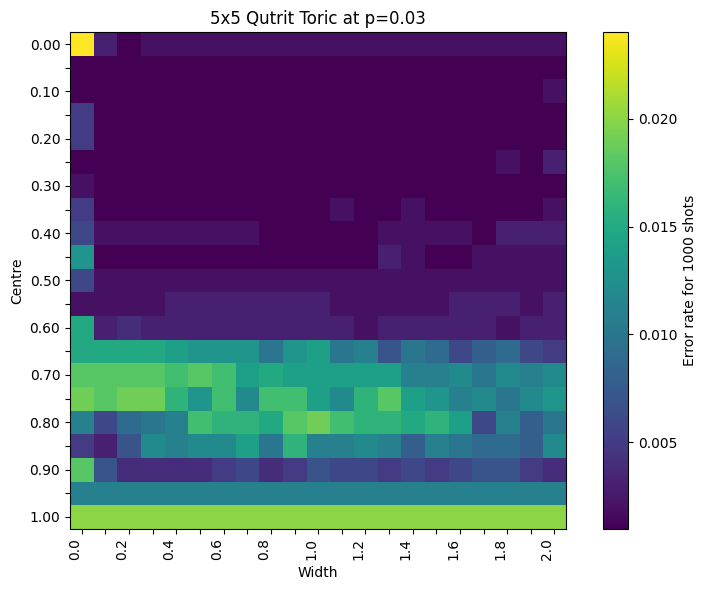

In [37]:
num_trials = 1000

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / num_trials)

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 2 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' if wi % 2 == 0 else ' ' for wi, w in enumerate(width)])
plt.setp(ax.get_xticklabels(), rotation=90, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label=f"Error rate for {num_trials} shots")

ax.set_title("5x5 Qutrit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


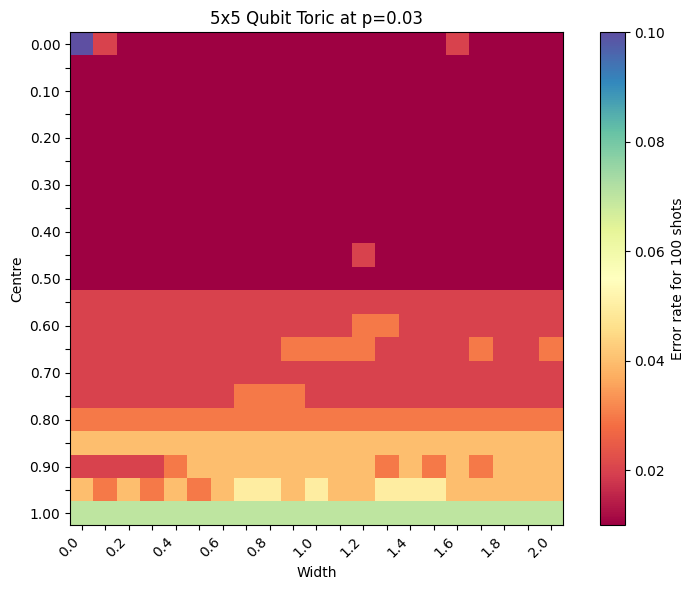

In [ ]:
num_trials = 100

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / num_trials, cmap="Spectral")

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 2 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' if wi % 2 == 0 else ' ' for wi, w in enumerate(width)])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label=f"Error rate for {num_trials} shots")

ax.set_title("5x5 Qubit Toric at p=0.03")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


In [2]:
field = Field(5)
x, y = Monomial(field, 'x'), Monomial(field, 'y')

# [[30, 4, 5]]_5^5
a, b = 1 + y + x**2*y**2, 2 + 3*x
bb = BivariateBicycle(a, b, 5, 3, 1)

hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

p = 0.03
num_trials = 500

max_iter = 30
first_iter = 40
solutions = 1
relays = 5

centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)

print(f'Centre: {centre}')
print(f'Width: {width}')


Centre: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
Width: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


In [ ]:
print(f'Setting up error channel for p = {p}...')
n_qudits = hx.shape[1]
channel_prob_x = np.ones(n_qudits) * p
x_prior = np.zeros((n_qudits, field.p), dtype=float)

for i, prob in enumerate(channel_prob_x):
    x_prior[i, 0] = 1 - prob
    for j in range(1, field.p):
        x_prior[i, j] = prob / (field.p - 1)

print('Starting trials...')
results = np.zeros((len(centre), len(width)))

for ci, c in enumerate(centre):
    for wi, w in enumerate(width):
        # Set seed
        np.random.seed(27)

        failures = 0

        for t in range(num_trials):
            # Set up random weights
            mem_weight = np.zeros((n_qudits, field.p, relays))
            mem_weight[:, :, 0] = c
            mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

            # mem_weight = np.zeros((n_qudits, field.p, relays))
            # mem_weight[:, :, 0] = c
            # rand = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, relays - 1))
            # for i in range(0, field.p):
            #     mem_weight[:, i, 1:] = rand

            # Set up decoder
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            # relaybp = RelayDecoderF32(hx, error_priors=channel_prob_x, gamma0=c, pre_iter=first_iter, num_sets=relays, set_max_iter=max_iter, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)

            # Generate syndrome
            error = np.zeros(n_qudits, dtype=int)
            error_mask = np.random.rand(n_qudits) < p
            for i in np.where(error_mask)[0]:
                error[i] = np.random.randint(1, field.p)
            syndrome = (hx @ error) % field.p

            # Decode
            guessed_error, decoder_success = relaybp.decode(syndrome, metric=False, debug=False)
            # syndrome = syndrome.astype(np.uint8)
            # guessed_error = relaybp.decode(syndrome)
            error_difference = (error - guessed_error) % field.p

            logical_effect = (np.array(lx) @ error_difference) % field.p

            # Check success
            if np.any(logical_effect != 0):
                failures += 1

        results[ci, wi] = failures
        print(f'Finished {ci+1}/{len(centre)} centres and {wi+1}/{len(width)} widths.')

print('Completed simulation')


Setting up error channel for p = 0.03...
Starting trials...
Finished 1/21 centres and 1/21 widths.
Finished 1/21 centres and 2/21 widths.
Finished 1/21 centres and 3/21 widths.
Finished 1/21 centres and 4/21 widths.
Finished 1/21 centres and 5/21 widths.
Finished 1/21 centres and 6/21 widths.
Finished 1/21 centres and 7/21 widths.
Finished 1/21 centres and 8/21 widths.
Finished 1/21 centres and 9/21 widths.
Finished 1/21 centres and 10/21 widths.
Finished 1/21 centres and 11/21 widths.
Finished 1/21 centres and 12/21 widths.
Finished 1/21 centres and 13/21 widths.
Finished 1/21 centres and 14/21 widths.
Finished 1/21 centres and 15/21 widths.
Finished 1/21 centres and 16/21 widths.
Finished 1/21 centres and 17/21 widths.
Finished 1/21 centres and 18/21 widths.
Finished 1/21 centres and 19/21 widths.
Finished 1/21 centres and 20/21 widths.


### Circuit Level

In [ ]:
d = 5
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals
n_qudits = hx.shape[1]

x_order = ['idle', 0, 3, 1, 2]
z_order = [0, 3, 1, 2, 'idle']
num_cycles = d

max_iter = 30
first_iter = 40
solutions = 1
relays = 5

circ = construct_sm_circuit(bb, x_order, z_order)


In [ ]:
centre = np.linspace(0.0, 1, 21)
width = np.linspace(0.0, 2, 21)

num_trials = 150
p = 0.003
error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, channel_prob_x, channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)
n_errors = short_hx_eff.shape[1]

print(f'Centre: {centre}')
print(f'Width: {width}')


Centre: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
Width: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]


In [ ]:
print(f'Starting full trials over physical error rate {p}')

results = np.zeros((len(centre), len(width)))
# Generate prior
x_prior = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
for i, prob in enumerate(channel_prob_x):
    x_prior[i, 0] = 1 - prob
    for j in range(1, field.p):
        x_prior[i, j] = prob / (field.p - 1)

for ci, c in enumerate(centre):
    for wi, w in enumerate(width):
        # Set seed
        np.random.seed(2728)

        failures = 0

        for t in range(num_trials):
            mem_weight = np.zeros((n_errors, field.p, relays))
            mem_weight[:, :, 0] = c
            mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_errors, field.p, relays - 1))

            # mem_weight = np.zeros((n_errors, field.p, relays))
            # mem_weight[:, :, 0] = c
            # rand = np.random.uniform(c - w/2, c + w/2, size=(n_errors, relays - 1))
            # for i in range(0, field.p):
            #     mem_weight[:, i, 1:] = rand
            
            # Set up decoder
            relaybp = RelayBP(field, short_hx_eff.toarray(), x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            # relaybp = RelayDecoderF32(short_hx_eff.toarray(), error_priors=np.array(channel_prob_x), gamma0=c, pre_iter=first_iter, num_sets=relays, set_max_iter=max_iter, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)

            # Generate noisy circ
            noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
            
            # Simulate noisy circ
            x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

            # Calculate true logical effect
            x_state_data_qudits = [x_state[bb.qudits_dict[qudit]] for qudit in bb.data_qudits]
            x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
            
            # Syndrome sparsification
            x_syndrome_history_copy = x_syndrome_history.copy()
            for check in bb.Zchecks:
                pos = x_syndrome_map[check]
                assert len(pos) == num_cycles + 2
                for row in range(1, num_cycles + 2):
                    x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
            x_syndrome_history %= field.p

            # Decode
            guessed_error, decoder_success, posterior = relaybp.decode(x_syndrome_history, metric=False, debug=True)
            # x_syndrome_history = x_syndrome_history.astype(np.uint8)
            # guessed_error = relaybp.decode(x_syndrome_history)
            # bposd = BPOSD(field, short_hx_eff.toarray(), x_prior, max_iter=max_iter)
            # guessed_error, _ = bposd.decode(x_syndrome_history)
            # assert np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history)

            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures += 1
                continue
            
            # Check logical effect
            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            k = len(lx)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures += 1

        results[ci, wi] = failures
        print(f'Finished {ci+1}/{len(centre)} centres and {wi+1}/{len(width)} widths.')
print('Completed simulation')


In [ ]:
results


In [ ]:
results = np.array([[13.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 3.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  2.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  2., 2.,  2.,  2.,  2.,  2.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1., 2.,  2.,  2.,  1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  2.,  1.,  2.],
       [ 1.,  1.,  1.,  1.,  2.,  2.,  1.,  1.,  1.,  1.,  1.,  2.,  1., 2.,  1.,  1.,  2.,  2.,  2.,  2.,  2.],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2., 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  1.,  2.,  2., 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
       [ 2.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  2.,  2.,  2., 2.,  2.,  2.,  1.,  2.,  2.,  2.,  2.],
       [ 2.,  2.,  2.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  2.,  2.,  3., 3.,  2.,  1.,  2.,  1.,  1.,  1.,  1.],
       [15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15.]])


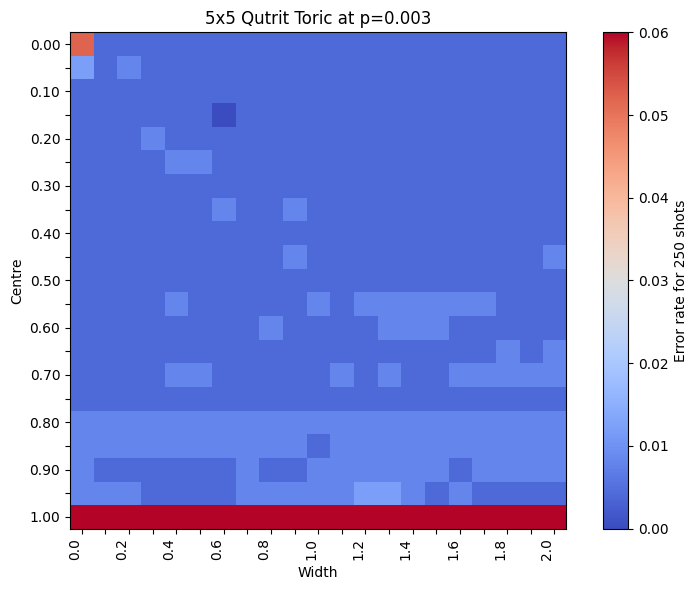

In [ ]:
num_trials = 250

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(results / num_trials, cmap='coolwarm')

# Set ticks
ax.set_yticks(np.arange(len(centre)))
ax.set_xticks(np.arange(len(width)))

# Set tick labels
ax.set_yticklabels([f'{c:.2f}' if ci % 2 == 0 else ' ' for ci, c in enumerate(centre)])
ax.set_xticklabels([f'{w:.1f}' if wi % 2 == 0 else ' ' for wi, w in enumerate(width)])
plt.setp(ax.get_xticklabels(), rotation=90, ha="right")

# Colorbar
plt.colorbar(im, ax=ax, label=f"Error rate for {num_trials} shots")

ax.set_title("5x5 Qutrit Toric at p=0.003")
ax.set_ylabel("Centre")
ax.set_xlabel("Width")

plt.tight_layout()
plt.show()


## Part II: Surface Code under Code Capacity against HDRG

## Part III: Surface and BB Codes under Circuit Level against Qubits

## Part IV: BB Codes under Code Capacity against IPB

## Part V: Exhaustive Simulation with Metrics